# Module 2 (Assignment 2)

## Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)

print("Libraries imported successfully")

Libraries imported successfully


## Question 1: To understand and implement the basic working of an artificial neuron using Python.
**Aim:** Understand and implement the basic working of an artificial neuron.

**Concept:**
- An artificial neuron is the smallest unit of a neural network.
- It combines inputs linearly, then applies a non-linear activation.
- Every larger network is just many of these units connected together.

**What the code does:**
- Defines a fixed array of `inputs` and a matching array of `weights`.
- Defines a `bias` value that shifts the result independent of the inputs.
- Defines a `step_function` that outputs 1 if its input is ≥ 0, else 0.
- Computes the weighted sum `z = (inputs · weights) + bias` using `np.dot`.
- Passes `z` through the step function to get the neuron's final output.
- Prints both `z` and the final output.

In [2]:
# Inputs to the neuron
inputs = np.array([0.5, 0.8, 0.2])

# Weight for each input (how important that input is)
weights = np.array([0.4, 0.7, 0.3])

# Bias term (shifts the result independently of the inputs)
bias = 0.1

# Simple step activation function
def step_function(x):
    return 1 if x >= 0 else 0

# Weighted sum: z = (inputs . weights) + bias
z = np.dot(inputs, weights) + bias

# Apply the activation function to get the final neuron output
output = step_function(z)

print("Weighted sum (z):", z)
print("Neuron output:", output)

Weighted sum (z): 0.92
Neuron output: 1


**Result & Analysis:**
- The weighted sum comes out to `z = 0.92`.
- Since `z ≥ 0`, the step function fires and the neuron outputs `1`.
- Confirms the two-stage process of every neuron: linear combination → non-linear decision.

## Question 2: To understand and implement the basic working of an artificial neuron using Python.
**Aim:** Implement the weighted sum of inputs and bias used in an artificial neuron.

**Concept:**
- This is the calculation that happens *inside* a neuron, before activation.
- It is the same `z` computed in Q1, but broken into visible individual steps.
- This exact calculation repeats for every neuron in every layer of a network.

**What the code does:**
- Defines `inputs`, `weights` and a `bias` (4 values this time, some negative).
- Step 1: multiplies `inputs` and `weights` element-wise → `products`.
- Step 2: adds up all the `products` using `np.sum` → `weighted_sum`.
- Step 3: adds the `bias` to the `weighted_sum` to get the final value `z`.
- Prints the result after each of the three steps.

In [3]:
inputs = np.array([1.5, 2.0, -1.0, 0.5])
weights = np.array([0.2, -0.4, 0.6, 0.1])
bias = 0.3

# Step 1: multiply each input with its corresponding weight
products = inputs * weights
print("Input x Weight products:", products)

# Step 2: sum of the products
weighted_sum = np.sum(products)
print("Sum of products:", weighted_sum)

# Step 3: add the bias to get the final pre-activation value z
z = weighted_sum + bias
print("Weighted sum with bias (z):", z)

Input x Weight products: [ 0.3  -0.8  -0.6   0.05]
Sum of products: -1.05
Weighted sum with bias (z): -0.75


**Result & Analysis:**
- The four products are `[0.3, -0.8, -0.6, 0.05]`.
- These sum to `-1.05`.
- Adding the bias (`0.3`) gives the final pre-activation value `z = -0.75`.
- Being negative, this `z` would make the Q1-style step function output `0`.

## Question 3: To implement and visualize Sigmoid, Tanh, and ReLU activation functions using Python.
**Aim:** Implement and visualize Sigmoid, Tanh, and ReLU activation functions.

**Concept:**
- Activation functions add non-linearity — without them, stacking layers is pointless.
- **Sigmoid** squashes values into (0, 1); good for probabilities, can vanish for extreme x.
- **Tanh** squashes values into (-1, 1); zero-centered, often trains faster than Sigmoid.
- **ReLU** passes positive values through unchanged and clips negatives to 0; cheap and the most common choice for hidden layers today.

**What the code does:**
- Creates 200 evenly spaced x-values from -10 to 10 using `np.linspace`.
- Defines `sigmoid()`, `tanh()`, and `relu()` as small functions.
- Creates a figure with 3 subplots side by side.
- Plots each activation function against `x` in its own subplot with a title.
- Displays all three plots together with `plt.show()`.

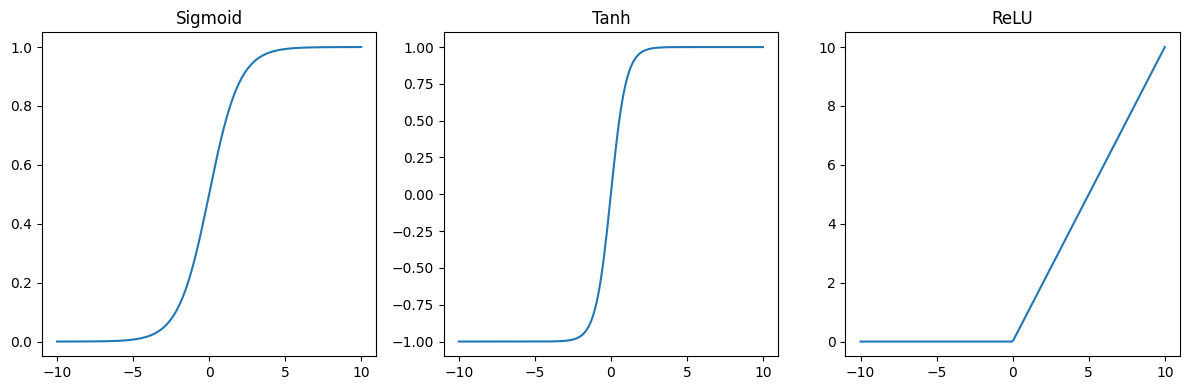

In [4]:
x = np.linspace(-10, 10, 200)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, sigmoid(x))
plt.title("Sigmoid")

plt.subplot(1, 3, 2)
plt.plot(x, tanh(x))
plt.title("Tanh")

plt.subplot(1, 3, 3)
plt.plot(x, relu(x))
plt.title("ReLU")

plt.tight_layout()
plt.show()

**Result & Analysis:**
- Sigmoid shows the expected S-curve, flattening near 0 and 1 at the extremes.
- Tanh shows the same S-shape but centered on 0, ranging from -1 to 1.
- ReLU is flat at 0 for all negative x, then rises linearly for positive x.
- All three match their mathematical definitions exactly.

## Question 4: To create a simple single-layer neural network using Python.
**Aim:** Create a simple single-layer neural network using Python.

**Concept:**
- A single-layer network (perceptron) connects inputs directly to the output — no hidden layer.
- It can only learn **linearly separable** problems.
- The AND logic gate is linearly separable, so a perceptron can learn it fully.
- Learning happens via the **perceptron rule**: update weights only when a prediction is wrong.

**What the code does:**
- Defines the AND-gate truth table as `X` (inputs) and `y` (expected outputs).
- Initializes `weights` to zero and `bias` to 0.
- Loops for 10 epochs; for every training example:
  - Computes `z = dot(X[i], weights) + bias` and applies the step function.
  - Compares prediction to the actual value to get an `error` (0, +1, or -1).
  - Updates `weights` and `bias` proportionally to `learning_rate * error`.
- After training, tests the network on all 4 AND combinations and prints predictions vs actuals.

In [5]:
# AND gate: inputs and expected outputs
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

# Initialize weights and bias to zero
weights = np.zeros(2)
bias = 0
learning_rate = 0.1

def step_function(x):
    return 1 if x >= 0 else 0

# Train the single-layer network using the perceptron learning rule
for epoch in range(10):
    for i in range(len(X)):
        z = np.dot(X[i], weights) + bias
        prediction = step_function(z)
        error = y[i] - prediction          # 0 if correct, else +1 or -1
        weights = weights + learning_rate * error * X[i]
        bias = bias + learning_rate * error

print("Final weights:", weights)
print("Final bias:", bias)

# Test the trained network on all four combinations
for i in range(len(X)):
    z = np.dot(X[i], weights) + bias
    print(f"Input: {X[i]}, Predicted: {step_function(z)}, Actual: {y[i]}")

Final weights: [0.2 0.1]
Final bias: -0.20000000000000004
Input: [0 0], Predicted: 0, Actual: 0
Input: [0 1], Predicted: 0, Actual: 0
Input: [1 0], Predicted: 0, Actual: 0
Input: [1 1], Predicted: 1, Actual: 1


**Result & Analysis:**
- Final weights converge to approximately `[0.2, 0.1]` with bias ≈ `-0.2`.
- All 4 test predictions match the actual AND-gate outputs exactly.
- Confirms the single-layer network fully learned the AND gate, as expected since it is linearly separable.

## Keras/TensorFlow Import
Needed from this point on, since Questions 5, 8, 9 and 10 use the **Keras** API (part of TensorFlow) to define, train, and evaluate networks.

In [6]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-c", "import tensorflow as tf; print('TensorFlow:', tf.__version__)"],
    capture_output=True,
    text=True
)

print("RETURN CODE:", result.returncode)
print("OUTPUT:")
print(result.stdout)
print("ERROR:")
print(result.stderr)

RETURN CODE: 0
OUTPUT:
TensorFlow: 2.15.1

ERROR:
2026-09-07 00:12:44.770610: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.




In [7]:
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow/Keras imported successfully")


TensorFlow/Keras imported successfully


## Question 5: To create a Multilayer Perceptron (MLP) with input, hidden, and output layers using Keras/TensorFlow.
**Aim:** Create an MLP with input, hidden, and output layers using Keras/TensorFlow.

**Concept:**
- An MLP adds one or more **hidden layers** between input and output.
- Hidden layers let the network learn non-linear patterns a single layer cannot.
- **Softmax** on the output layer converts raw scores into class probabilities that sum to 1 — required for multi-class classification.

**What the code does:**
- Loads the **Iris dataset** (4 input features, 3 output classes) only to fix the layer sizes.
- Creates an empty `keras.Sequential()` model.
- Adds an `Input` layer of shape `(4,)` matching the 4 features.
- Adds a hidden `Dense(8, activation="relu")` layer.
- Adds an output `Dense(3, activation="softmax")` layer for the 3 iris classes.
- Calls `model.summary()` to print the architecture and parameter counts.

In [8]:
# Load Iris dataset (4 input features, 3 output classes)
iris = load_iris()
X = iris.data
y = iris.target

# Build a simple MLP: Input -> Hidden -> Output
model = keras.Sequential()
model.add(layers.Input(shape=(4,)))
model.add(layers.Dense(8, activation="relu"))     # hidden layer
model.add(layers.Dense(3, activation="softmax"))  # output layer (3 classes)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 40        
                                                                 
 dense_1 (Dense)             (None, 3)                 27        
                                                                 
Total params: 67 (268.00 Byte)
Trainable params: 67 (268.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Result & Analysis (expected once run with TensorFlow installed):**
- `model.summary()` lists 2 layers: the 8-neuron hidden Dense layer and the 3-neuron Softmax output layer, plus their trainable parameter counts.
- Confirms the architecture matches the design: 4 inputs → 8 hidden neurons → 3 output classes.

## Question 6: To apply Gradient Descent for updating the weights of a simple neural network during training.
**Aim:** Apply Gradient Descent for updating the weights of a simple neural network during training.

**Concept:**
- Gradient Descent is the core optimization algorithm behind neural network training.
- It computes the **gradient** (slope) of a loss function with respect to each parameter.
- It then moves the parameter a small step **opposite** to that gradient, since this direction reduces the loss.
- The **learning rate** controls how large that step is.

**What the code does:**
- Builds a tiny dataset following `y = 2x`.
- Initializes `w = 0.0` and `b = 0.0`.
- Repeats for 50 epochs:
  - Computes predictions `y_pred = w*X + b` and the `error`.
  - Computes gradients `dw` and `db` of the Mean Squared Error loss.
  - Updates `w` and `b` by subtracting `learning_rate * gradient`.
  - Every 10th epoch, prints the current `w`, `b`, and `loss`.
- Prints the final learned `w` and `b`.

In [9]:
# Simple dataset following y = 2x
X = np.array([1, 2, 3, 4], dtype=float)
y = np.array([2, 4, 6, 8], dtype=float)

# Initialize weight and bias
w = 0.0
b = 0.0
learning_rate = 0.01

# Gradient Descent loop
for epoch in range(50):
    y_pred = w * X + b
    error = y_pred - y

    # Gradients of the Mean Squared Error loss w.r.t. w and b
    dw = np.mean(2 * error * X)
    db = np.mean(2 * error)

    # Move w and b opposite to the gradient to reduce the loss
    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 10 == 0:
        loss = np.mean(error ** 2)
        print(f"Epoch {epoch}: w={w:.3f}, b={b:.3f}, loss={loss:.3f}")

print("\nFinal weight:", w)
print("Final bias:", b)

Epoch 0: w=0.300, b=0.100, loss=30.000
Epoch 10: w=1.559, b=0.508, loss=0.833
Epoch 20: w=1.767, b=0.559, loss=0.075
Epoch 30: w=1.805, b=0.553, loss=0.052
Epoch 40: w=1.816, b=0.539, loss=0.049

Final weight: 1.821302464002945
Final bias: 0.5247594267759913


**Result & Analysis:**
- Loss falls sharply from `30.0` (epoch 0) to under `0.05` by epoch 30.
- Weight `w` climbs from `0` towards ≈ `1.82`; bias `b` settles around `0.52`.
- This approaches the true relationship `y = 2x` (`w = 2, b = 0`), and would keep improving with more epochs — demonstrating gradient descent discovering the correct weight purely by minimizing error.

## Question 7: To understand and implement the basic concept of Backpropagation for training a neural network.
**Aim:** Understand and implement the basic concept of Backpropagation for training a neural network.

**Concept:**
- Backpropagation **calculates** the gradients that Gradient Descent (Q6) then uses to update weights, for every layer of a multi-layer network.
- It works in two passes: a **forward pass** (input → hidden → output) and a **backward pass** (propagating the output error back through the network using the chain rule).
- The **XOR problem** is used because, unlike AND in Q4, it is **not linearly separable** — a single layer cannot solve it, which is exactly why a hidden layer + backpropagation is needed.

**What the code does:**
- Defines `sigmoid()` and its derivative `sigmoid_derivative()`.
- Sets up the XOR truth table as `X` and `y`.
- Randomly initializes weights `w1, b1` (input→hidden) and `w2, b2` (hidden→output).
- Repeats for 2000 epochs:
  - **Forward pass:** computes `hidden_output` then `final_output`.
  - Computes the `error` between prediction and actual.
  - **Backward pass:** computes `d_output` then `d_hidden` using the chain rule.
  - Updates `w1, b1, w2, b2` using these gradients.
  - Every 500th epoch, prints the current loss.
- Prints the final predictions after training.

In [10]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# XOR dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

np.random.seed(1)

# Weights: 2 inputs -> 2 hidden neurons -> 1 output neuron
w1 = np.random.uniform(-1, 1, (2, 2))
b1 = np.zeros((1, 2))
w2 = np.random.uniform(-1, 1, (2, 1))
b2 = np.zeros((1, 1))

learning_rate = 0.5

for epoch in range(2000):
    # Forward pass
    hidden_output = sigmoid(np.dot(X, w1) + b1)
    final_output = sigmoid(np.dot(hidden_output, w2) + b2)

    # Error at the output
    error = y - final_output

    # Backward pass: propagate the error from output layer back to hidden layer
    d_output = error * sigmoid_derivative(final_output)
    d_hidden = d_output.dot(w2.T) * sigmoid_derivative(hidden_output)

    # Update weights and biases using the computed gradients
    w2 += hidden_output.T.dot(d_output) * learning_rate
    b2 += np.sum(d_output, axis=0, keepdims=True) * learning_rate
    w1 += X.T.dot(d_hidden) * learning_rate
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * learning_rate

    if epoch % 500 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

print("\nFinal predictions:")
print(final_output)

Epoch 0, Loss: 0.2761
Epoch 500, Loss: 0.1850
Epoch 1000, Loss: 0.0201
Epoch 1500, Loss: 0.0053

Final predictions:
[[0.04619359]
 [0.94428896]
 [0.94446364]
 [0.05577881]]


**Result & Analysis:**
- Loss falls steadily from `0.276` (epoch 0) to about `0.005` (epoch 1500).
- Final predictions ≈ `[0.05, 0.94, 0.94, 0.06]`, which round to `[0, 1, 1, 0]`.
- This exactly matches the true XOR outputs — confirming the hidden layer + backpropagation solved a problem the single-layer network in Q4 structurally could not.

## Question 8: To train a simple neural network model on a dataset using Keras/TensorFlow.
**Aim:** Train a simple neural network model on a dataset using Keras/TensorFlow.

**Concept:**
- Real training needs a **train/test split** so the model can be evaluated on unseen data.
- **Feature scaling** (`StandardScaler`) helps neural networks train more effectively.
- **Compiling** a model means choosing an optimizer, a loss function, and metrics to track.
- `model.fit()` automates exactly the forward pass + backpropagation + gradient descent steps implemented manually in Q6 and Q7.

**What the code does:**
- Loads the Iris dataset and splits it 80/20 into train/test sets (stratified by class).
- Fits a `StandardScaler` on the training data only, then scales both train and test sets.
- Builds a Sequential model: Input(4) → Dense(16, relu) → Dense(8, relu) → Dense(3, softmax).
- Compiles it with the `adam` optimizer, `sparse_categorical_crossentropy` loss (suited to integer class labels), and `accuracy` as the tracked metric.
- Trains it for 30 epochs with `batch_size=8`, holding out 20% of the training data for validation.

In [11]:
# Load and split the Iris dataset
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42, stratify=iris.target
)

# Scale the features (fit only on training data to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a simple neural network
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

# Compile the model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
history = model.fit(X_train_scaled, y_train,
                     epochs=30, batch_size=8,
                     validation_split=0.2, verbose=1)


Epoch 1/30


12/12 [==============================] - 1s 22ms/step - loss: 1.1162 - accuracy: 0.3750 - val_loss: 1.0833 - val_accuracy: 0.2500
Epoch 2/30
12/12 [==============================] - 0s 4ms/step - loss: 1.0576 - accuracy: 0.4688 - val_loss: 1.0318 - val_accuracy: 0.3750
Epoch 3/30
12/12 [==============================] - 0s 4ms/step - loss: 1.0048 - accuracy: 0.4896 - val_loss: 0.9870 - val_accuracy: 0.4583
Epoch 4/30
12/12 [==============================] - 0s 5ms/step - loss: 0.9619 - accuracy: 0.5104 - val_loss: 0.9431 - val_accuracy: 0.5000
Epoch 5/30
12/12 [==============================] - 0s 4ms/step - loss: 0.9196 - accuracy: 0.5521 - val_loss: 0.9062 - val_accuracy: 0.5833
Epoch 6/30
12/12 [==============================] - 0s 4ms/step - loss: 0.8815 - accuracy: 0.5729 - val_loss: 0.8709 - val_accuracy: 0.6250
Epoch 7/30
12/12 [==============================] - 0s 5ms/step - loss: 0.8461 - accuracy: 0.5938 - val_loss: 0.8364 - val_accuracy: 0.6667
Epoch 8/30
12/12

**Result & Analysis (expected once run with TensorFlow installed):**
- The training log prints `loss`/`accuracy` (training) and `val_loss`/`val_accuracy` (validation) for each of the 30 epochs.
- On Iris, training accuracy typically climbs above 90% within a small number of epochs, since the classes are fairly well separated.

## Question 9: To evaluate the performance of a trained neural network using suitable evaluation metrics in Python.
**Aim:** Evaluate the performance of a trained neural network using suitable evaluation metrics.

**Concept:**
- Accuracy alone doesn't tell the full story of model quality.
- **Precision:** of predictions for a class, how many were actually correct?
- **Recall:** of actual members of a class, how many were correctly found?
- **F1-score:** harmonic mean of precision and recall — a single balanced score.
- **Confusion Matrix:** shows exactly which classes are confused with which.

**What the code does:**
- Uses the model trained in Question 8 to predict class probabilities on the **test set**.
- Converts probabilities to class labels with `np.argmax`.
- Computes `accuracy_score`, `precision_score`, `recall_score`, and `f1_score` (weighted average across the 3 classes).
- Prints all four metrics.
- Builds and displays a Confusion Matrix comparing predicted vs actual classes.

1/1 [==============================] - 0s 191ms/step
Accuracy: 0.8333333333333334
Precision: 0.8498168498168498
Recall: 0.8333333333333334
F1 Score: 0.8294970161977834


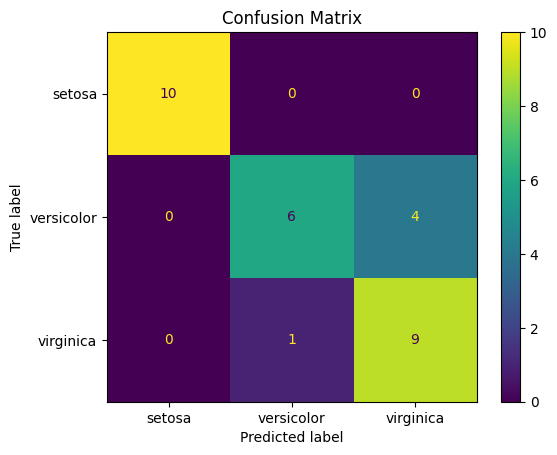

In [12]:
# Predict on test data
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)   # pick the class with the highest probability

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=iris.target_names).plot()
plt.title("Confusion Matrix")
plt.show()

**Result & Analysis (expected once run with TensorFlow installed):**
- All four metrics should be high and close to each other (typically 0.90+) since Iris is an easy, well-separated dataset.
- Most confusion-matrix values should fall on the diagonal (correct predictions).
- Any confusion is most likely between *versicolor* and *virginica*, which overlap slightly in feature space.

## Question 10: To design, train, and evaluate a complete Artificial Neural Network-based classification system using Python and Keras/TensorFlow by integrating input features, hidden layers, activation functions, training, and model evaluation.
**Aim:** Design, train, and evaluate a complete ANN-based classification system by integrating input features, hidden layers, activation functions, training, and evaluation.

**Concept:**
- Brings together everything from Q1–Q9 into one **end-to-end pipeline**.
- Applied to a new dataset (**Wine**: 13 features, 3 cultivar classes) to show it generalizes beyond Iris.
- Same Load → Preprocess → Split → Scale → Build → Train → Evaluate workflow used throughout.

**What the code does:**
- **(1)** Loads the Wine dataset and prints its shape and number of classes.
- **(2)** Splits it 80/20 into train/test sets (stratified).
- **(3)** Scales the features with `StandardScaler`.
- **(4)** Builds the ANN: Input(13) → Dense(32, relu) → Dense(16, relu) → Dense(3, softmax).
- **(5)** Compiles it with `adam`, `sparse_categorical_crossentropy`, and `accuracy`.
- **(6)** Trains for 30 epochs with `batch_size=8` and a validation split.
- **(7)** Evaluates final test loss and test accuracy with `model.evaluate()`.
- **(8)** Prints a full `classification_report` (precision/recall/F1 per class).
- **(9)** Builds and displays the Confusion Matrix for the 3 wine classes.

Data shape: (178, 13) | Classes: 3
Epoch 1/30
15/15 [==============================] - 1s 20ms/step - loss: 1.0391 - accuracy: 0.5221 - val_loss: 0.8788 - val_accuracy: 0.6897
Epoch 2/30
15/15 [==============================] - 0s 6ms/step - loss: 0.8807 - accuracy: 0.6814 - val_loss: 0.7718 - val_accuracy: 0.8621
Epoch 3/30
15/15 [==============================] - 0s 4ms/step - loss: 0.7678 - accuracy: 0.8230 - val_loss: 0.6833 - val_accuracy: 0.8966
Epoch 4/30
15/15 [==============================] - 0s 4ms/step - loss: 0.6669 - accuracy: 0.8850 - val_loss: 0.5832 - val_accuracy: 0.9655
Epoch 5/30
15/15 [==============================] - 0s 4ms/step - loss: 0.5706 - accuracy: 0.9469 - val_loss: 0.5036 - val_accuracy: 0.9655
Epoch 6/30
15/15 [==============================] - 0s 4ms/step - loss: 0.4823 - accuracy: 0.9735 - val_loss: 0.4179 - val_accuracy: 0.9655
Epoch 7/30
15/15 [==============================] - 0s 4ms/step - loss: 0.4039 - accuracy: 0.9823 - val_loss: 0.3443 - val_a

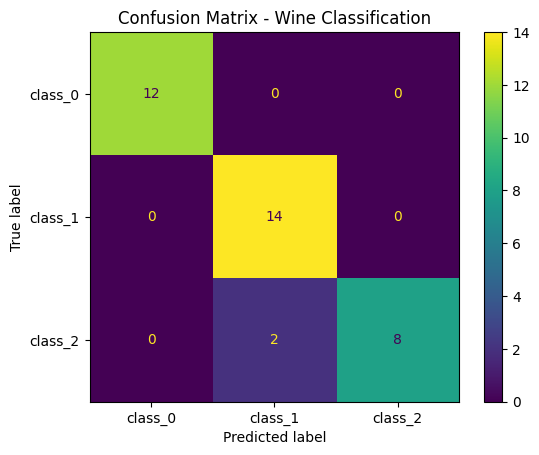

In [13]:
# 1. Load the dataset
wine = load_wine()
X = wine.data
y = wine.target
print("Data shape:", X.shape, "| Classes:", len(wine.target_names))

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Build the ANN: Input -> Hidden -> Hidden -> Output
model = keras.Sequential([
    layers.Input(shape=(X.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(len(wine.target_names), activation="softmax")
])

# 5. Compile the model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# 6. Train the model
history = model.fit(X_train_scaled, y_train,
                     epochs=30, batch_size=8,
                     validation_split=0.2, verbose=1)

# 7. Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# 8. Predictions and classification metrics
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=wine.target_names))

# 9. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names).plot()
plt.title("Confusion Matrix - Wine Classification")
plt.show()

**Result & Analysis (expected once run with TensorFlow installed):**
- The Wine dataset is small and well-separated, so test accuracy is typically high (often 95%+) within 30 epochs.
- The classification report should show strong precision/recall for all 3 cultivar classes.
- The confusion matrix should be close to a clean diagonal, confirming the full pipeline — from Q1's single neuron through Q9's evaluation metrics — works correctly end-to-end.